<a href="https://colab.research.google.com/github/kosar-am/rice-classification-cnn/blob/main/notebooks/02_tensorflow_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rice Classification Using TensorFlow


## Install and Import Libraries

In [1]:
# Install KaggleHub to access the dataset

!pip install -q kagglehub

In [2]:
# Import required libraries

import os
import kagglehub
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report


In [3]:

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Download Dataset

In [4]:
# Download the rice image dataset from Kaggle

dataset_path = kagglehub.dataset_download(
    "muratkokludataset/rice-image-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 219M/219M [00:03<00:00, 72.1MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1


## Define Dataset Path

In [5]:
# Define the path to the image dataset

rice_dataset_path = os.path.join(
    dataset_path,
    "Rice_Image_Dataset"
)

print(rice_dataset_path)

/root/.cache/kagglehub/datasets/muratkokludataset/rice-image-dataset/versions/1/Rice_Image_Dataset


## Define Dataset Parameters

In [6]:
# Define parameters for loading the image dataset

IMAGE_SIZE = (250, 250)
BATCH_SIZE = 32
SEED = 42

## Create Training and Validation Datasets


In [7]:
# Load 80% of the images as the training dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    rice_dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 75000 files belonging to 5 classes.
Using 60000 files for training.


In [8]:
# Load 20% of the images as the validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    rice_dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


In [9]:
print(train_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [10]:
print(validation_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 250, 250, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Inspect One Batch

In [11]:
# Get one batch from the training dataset

for images, labels in train_dataset.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 250, 250, 3)
Labels shape: (32,)


## Display Images from One Batch

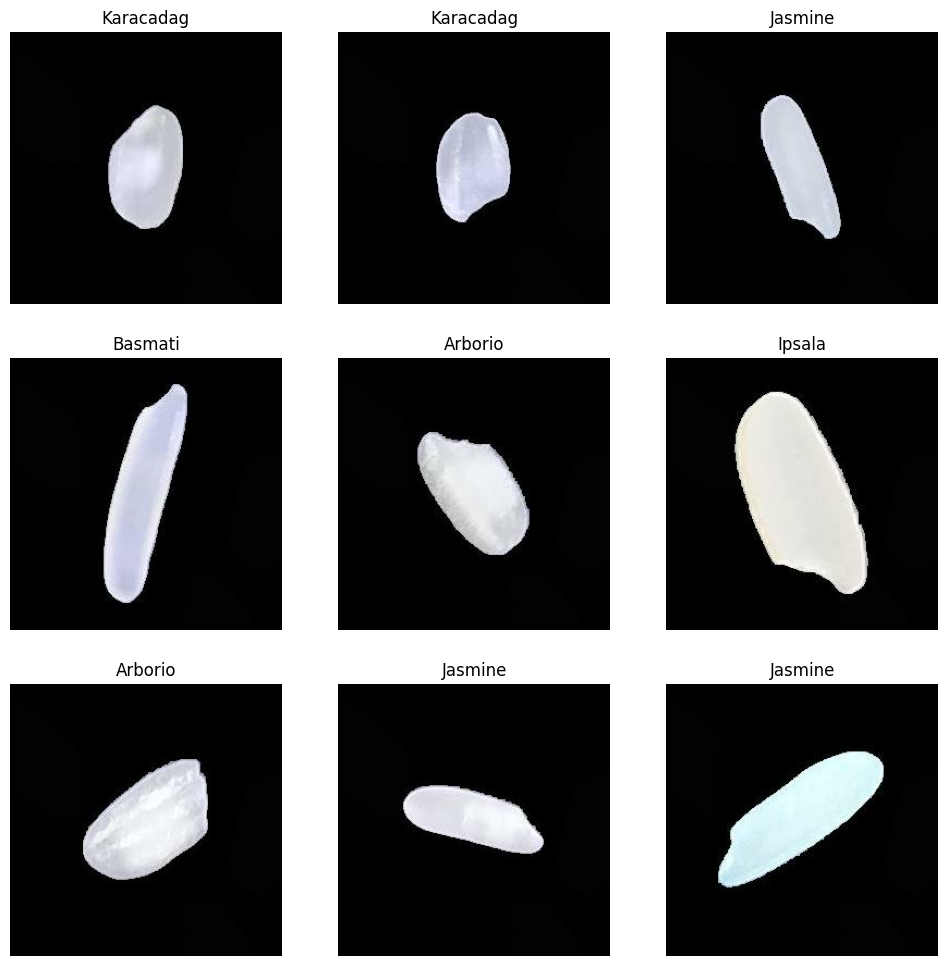

In [12]:
# Display images from the first training batch

import matplotlib.pyplot as plt

class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

    plt.show()

## Normalize Pixel Values

In [13]:
# Create a normalization layer

normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [14]:
# Apply normalization to training and validation datasets

normalized_train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

normalized_validation_dataset = validation_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

In [15]:
# Check pixel value range after normalization

for images, labels in normalized_train_dataset.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## Optimize Dataset Performance

In [16]:
# Improve data loading performance

AUTOTUNE = tf.data.AUTOTUNE

normalized_train_dataset = normalized_train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

normalized_validation_dataset = normalized_validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

## Data Augmentation

In [17]:
# Create data augmentation layers

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)

])

# Build the CNN Model

## Build a Simple CNN Baseline Model

In [18]:
# Build a simple CNN baseline model

baseline_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=len(class_names),
        activation="softmax"
    )
])

In [19]:
baseline_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 500000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    64,000,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,001,669 (244.15 MB)

 Trainable params: 64,001,669 (244.15 MB)

 Non-trainable params: 0 (0.00 B)

## Analysis

- Architecture is correct.
- However, the first Dense layer has about 64 million parameters.
- This is computationally expensive.
- We will build an improved CNN architecture.

# Build Improved CNN

In [20]:
# Build an improved CNN model with two convolutional blocks

improved_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=len(class_names),
        activation="softmax"
    )
])

In [21]:
improved_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,510,213 (120.20 MB)

 Trainable params: 31,510,213 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

### Model Analysis

The second convolutional block reduced the total number of parameters from approximately 64 million to 31.5 million. However, the first Dense layer still contains almost all trainable parameters, so the architecture remains computationally inefficient.

## Build a Deeper CNN Model

In [22]:
# Build a deeper CNN model with three convolutional blocks

deeper_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=len(class_names),
        activation="softmax"
    )
])

In [23]:
deeper_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    15,745,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,839,045 (60.42 MB)

 Trainable params: 15,839,045 (60.42 MB)

 Non-trainable params: 0 (0.00 B)

## Build an Efficient CNN Model

In [24]:
# Build an efficient CNN using Global Average Pooling

efficient_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(250, 250, 3)),

    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        units=128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        units=len(class_names),
        activation="softmax"
    )
])

In [25]:
efficient_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 250, 250, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 125, 125, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Efficient CNN

In [26]:
efficient_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Train the Efficient CNN

In [27]:
history = efficient_cnn.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 133s 67ms/step - accuracy: 0.8428 - loss: 0.3978 - val_accuracy: 0.9453 - val_loss: 0.1564
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 66ms/step - accuracy: 0.9456 - loss: 0.1498 - val_accuracy: 0.9755 - val_loss: 0.0745
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 66ms/step - accuracy: 0.9669 - loss: 0.0942 - val_accuracy: 0.9655 - val_loss: 0.0945
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 66ms/step - accuracy: 0.9744 - loss: 0.0736 - val_accuracy: 0.9890 - val_loss: 0.0342
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 123s 66ms/step - accuracy: 0.9797 - loss: 0.0590 - val_accuracy: 0.9859 - val_loss: 0.0393


## Visualize Training Performance

In [28]:
# Extract training history

train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(train_accuracy) + 1)

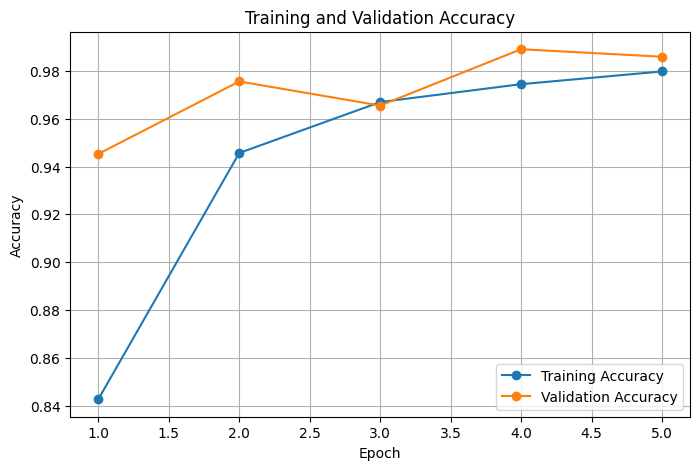

In [29]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracy, marker="o", label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

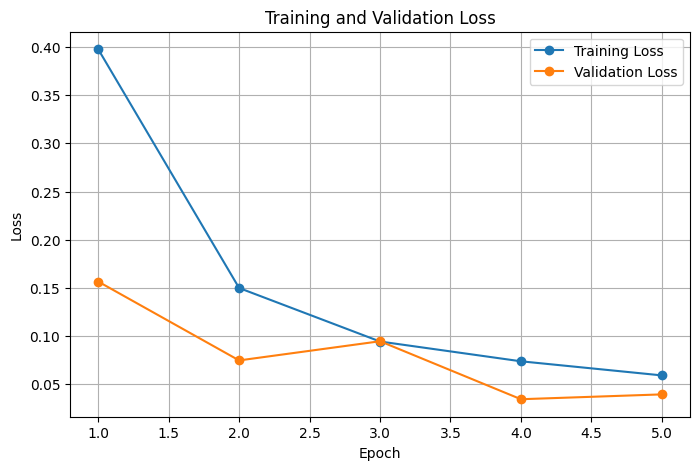

In [30]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Evaluate the Trained Model

In [31]:
# Evaluate the model on the validation dataset

validation_loss, validation_accuracy = efficient_cnn.evaluate(
    normalized_validation_dataset
)

print(f"Validation Loss: {validation_loss:.4f}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9859 - loss: 0.0393
Validation Loss: 0.0393
Validation Accuracy: 0.9859


## Generate Predictions for the Validation Dataset

In [32]:
# Generate predictions and collect true labels

import numpy as np

true_labels = []
predicted_labels = []

for images, labels in normalized_validation_dataset:
    predictions = efficient_cnn.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

print("Number of true labels:", len(true_labels))
print("Number of predictions:", len(predicted_labels))

Number of true labels: 15000
Number of predictions: 15000


In [33]:
# Display the first 10 true and predicted class labels

print("True labels:")
print(true_labels[:10])

print("\nPredicted labels:")
print(predicted_labels[:10])

True labels:
[1 3 3 2 2 1 2 4 4 2]

Predicted labels:
[1 3 3 2 2 1 2 4 4 2]


In [34]:
# Display class names for the first 10 predictions

for i in range(10):
    true_class = class_names[true_labels[i]]
    predicted_class = class_names[predicted_labels[i]]

    print(
        f"Image {i + 1}: "
        f"True = {true_class}, "
        f"Predicted = {predicted_class}"
    )

Image 1: True = Basmati, Predicted = Basmati
Image 2: True = Jasmine, Predicted = Jasmine
Image 3: True = Jasmine, Predicted = Jasmine
Image 4: True = Ipsala, Predicted = Ipsala
Image 5: True = Ipsala, Predicted = Ipsala
Image 6: True = Basmati, Predicted = Basmati
Image 7: True = Ipsala, Predicted = Ipsala
Image 8: True = Karacadag, Predicted = Karacadag
Image 9: True = Karacadag, Predicted = Karacadag
Image 10: True = Ipsala, Predicted = Ipsala


## Confusion Matrix

In [35]:


cm = confusion_matrix(
    y_true=true_labels,
    y_pred=predicted_labels
)

print(cm)

[[2956    0    1   71    1]
 [   0 3109    0    7    0]
 [   0    0 2898    0    0]
 [   5   19    0 2970    0]
 [  70    0    0   38 2855]]


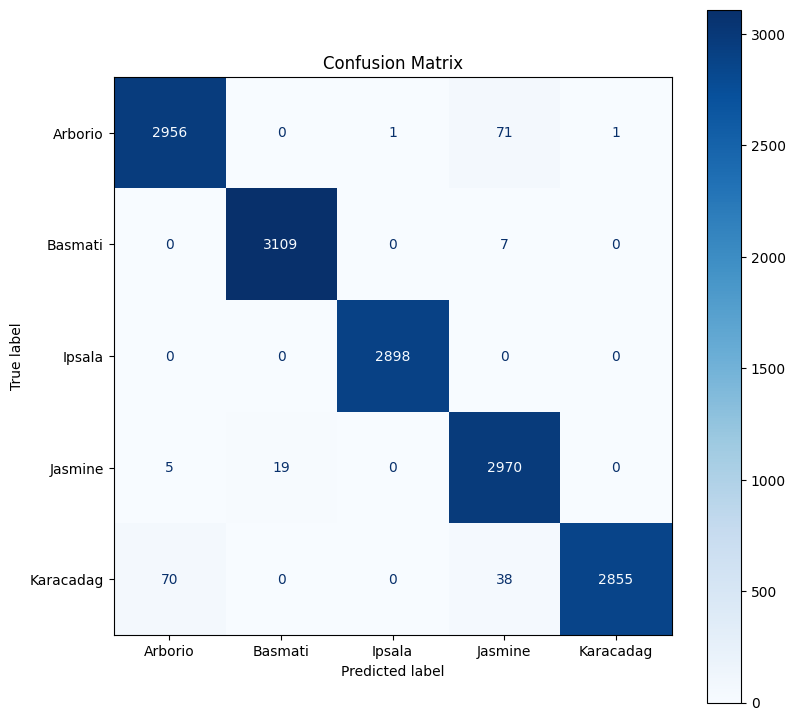

In [36]:


fig, ax = plt.subplots(figsize=(9,9))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.show()

In [37]:
# Classification Report
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     Arborio       0.98      0.98      0.98      3029
     Basmati       0.99      1.00      1.00      3116
      Ipsala       1.00      1.00      1.00      2898
     Jasmine       0.96      0.99      0.98      2994
   Karacadag       1.00      0.96      0.98      2963

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



## Predict a Single Image

In [38]:
# Get one batch from the validation dataset

for images, labels in normalized_validation_dataset.take(1):
    sample_image = images[0]
    true_label = labels[0]

In [39]:
# Add a batch dimension and make a prediction

image_batch = tf.expand_dims(sample_image, axis=0)

prediction = efficient_cnn.predict(
    image_batch,
    verbose=0
)

predicted_class_index = np.argmax(
    prediction[0]
)

confidence = np.max(
    prediction[0]
)

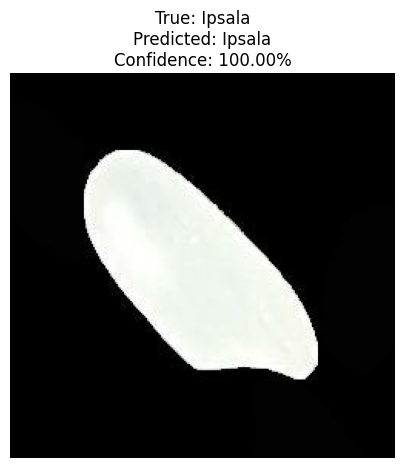

In [40]:
# Display the image and prediction result

plt.figure(figsize=(5, 5))

plt.imshow(sample_image.numpy())

plt.title(
    f"True: {class_names[true_label]}\n"
    f"Predicted: {class_names[predicted_class_index]}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

In [41]:
tf.expand_dims(sample_image, axis=0)

<tf.Tensor: shape=(1, 250, 250, 3), dtype=float32, numpy=
array([[[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        ...,

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         ...,
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]]], dty

In [42]:
print("Prediction probabilities:")
print(prediction[0])

print("\nPredicted class index:")
print(np.argmax(prediction[0]))

print("\nConfidence:")
print(np.max(prediction[0]))

Prediction probabilities:
[1.9681669e-12 5.4942498e-13 1.0000000e+00 6.3680954e-09 3.7682036e-24]

Predicted class index:
2

Confidence:
1.0


In [43]:
print(class_names[2])

Ipsala


## Save the Trained Model

In [57]:
MODEL_PATH = "/content/drive/MyDrive/My-Project/rice_cnn_model2026.keras"

efficient_cnn.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!
